In [1]:
import jax
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax.numpy as jnp
wanted_type_complex = jnp.complex128
wanted_type_real = jnp.float64
print("Devices:", jax.devices())
if not any(d.platform == "gpu" for d in jax.devices()):
    raise RuntimeError("JAX is not using a GPU.")
import sys
sys.path.insert(0, "/home/tmalasda/dev")
from cheb_ar import ChebAr
import numpy as np
import dynamiqs as dq
from scipy.special import jv
import matplotlib.pyplot as plt

Devices: [CudaDevice(id=0)]


In [2]:
n_a = 20
n_b = 8
alpha_sq = 6
eps_p = .1
eps_p_init = .1
kappa_b_init = .6 / 10.4 *5
E_J=37 * 2 * np.pi
phi_a=0.11
phi_b=0.204
g = np.sin(eps_p) * E_J * phi_a**2 * phi_b
print(kappa_b_init / g)

5.035178264225644


# Warm start

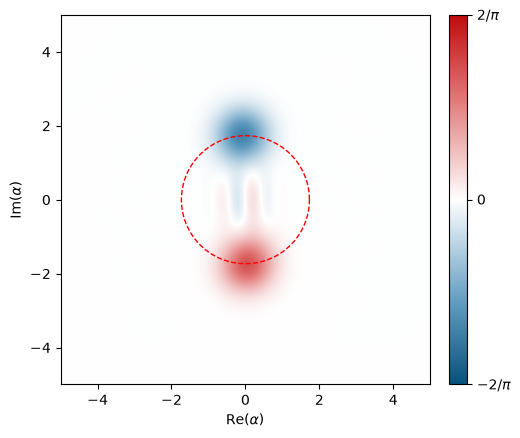

In [3]:
import json
def _from_jsonable(obj):
    """Recursively convert JSON types back to numpy/complex objects.
    
    ``{"real": ..., "imag": ...}`` dicts become complex numbers;
    lists become numpy arrays if they contain numeric/complex values.
    """
    if isinstance(obj, dict):
        # Complex number encoding
        if set(obj.keys()) == {"real", "imag"}:
            return complex(obj["real"], obj["imag"])
        # Regular dict: recurse on values
        return {k: _from_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        converted = [_from_jsonable(v) for v in obj]
        # Convert to numpy array if all elements are numeric or complex
        if all(isinstance(v, (int, float, complex, np.ndarray)) for v in converted):
            return np.array(converted)
        return converted
    return obj  # int, float, str → keep as-is


def load_json(path):
    """Load a JSON file and return a dict with numpy/complex values."""
    with open(path, "r") as f:
        raw = json.load(f)
    return _from_jsonable(raw)

data = load_json("/home/tmalasda/output/Cheb_Ar/13_07_2026/cheb_ar_vs_epsp_alphasq_6.json")[0]
x_ritz_warm  = data["x_ritz"]

rho_ritz_warm = dq.unvectorize(dq.asqarray(x_ritz_warm[:, None]))
rho_ritz_warm = dq.asqarray(dq.to_jax(rho_ritz_warm), dims=(n_a, n_b))
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz_warm,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

# Cheb-Ar

In [4]:
def build_ats_hamiltonian(
    n_a=20,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=0.1,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the rotating frame.

    Mirrors the operator/Hamiltonian cells of ``Chebyshev-Arnoldi.ipynb``.

    Returns
    -------
    Ham : dynamiqs time-dependent operator
        The rotating-frame Hamiltonian ``Ham_full_r``.
    jump_ops : list
        Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    phi_a_tot = phi_a*(a_tot + dq.dag(a_tot))
    phi_b_tot = phi_b*(b_tot + dq.dag(b_tot))

    non_linear_op = dq.sinm(phi_a_tot + phi_b_tot) - phi_a_tot - phi_b_tot

    H_drive = dq.modulated(
        lambda t: epsilon_d * jnp.cos(w_b*t),
        b_tot + dq.dag(b_tot)
        )

    H_0 = w_a*a_tot@dq.dag(a_tot) + w_b*b_tot@dq.dag(b_tot)

    Ham = H_0 + H_drive - 2*E_J*jnp.sin(epsilon_p)*non_linear_op 

    jump_ops = [
        jnp.sqrt(kappa_1) * a_tot,
        jnp.sqrt(kappa_b) * b_tot,
    ]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return Ham, jump_ops, T_block, params

In [5]:
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b_init)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)


In [6]:
params['g2']/2/np.pi*1e3

np.float64(4.560834202910811)

In [7]:
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)

In [8]:
x0 = solver.make_x0(seed=0)
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)

|██████████| 100.0% ◆ elapsed 499.65ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 465.38ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 454.58ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 425.91ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 414.59ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 405.12ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 396.93ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 392.39ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 394.28ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 390.36ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 386.01ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 384.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 386.62ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 387.44ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 390.76ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 392.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 387.64ms ◆

In [9]:
solver.setup_chebyshev(ritz_vals, margin=1e-2)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.29431904379464324-2.2668132519543797e-15j),
 'semi_re': np.float64(0.6588975186944049),
 'semi_im': np.complex128(0.8233117293151704-4.74973971121739e-16j),
 'ritz_bitflip': np.complex128(0.9632165624890482-2.9178104897983296e-15j),
 'vertex_x': np.complex128(0.9532165624890482-2.9178104897983296e-15j),
 'margin': 0.01,
 'max_level': 0.9900000000000001,
 'ritz_vals_enc': array([-0.1251624 -6.28609954e-01j, -0.12053744-6.28755079e-01j,
        -0.05718866-6.52947091e-01j, -0.04234451-6.66069666e-01j,
         0.00287098-6.76444376e-01j,  0.03083075-6.90536210e-01j,
         0.08047341-6.63081406e-01j,  0.1413844 -7.40975489e-01j,
         0.18781988-8.08303865e-01j,  0.19121452-6.76083373e-01j,
         0.23561754-7.82443481e-01j,  0.27154175-7.86007939e-01j,
         0.31757632-7.59108798e-01j,  0.37365919-7.82590885e-01j,
         0.41987027-7.30843455e-01j,  0.50891524-6.87886535e-01j,
         0.44955693-6.54113058e-01j,  0.56060292-6.46509514e-01j,
    

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


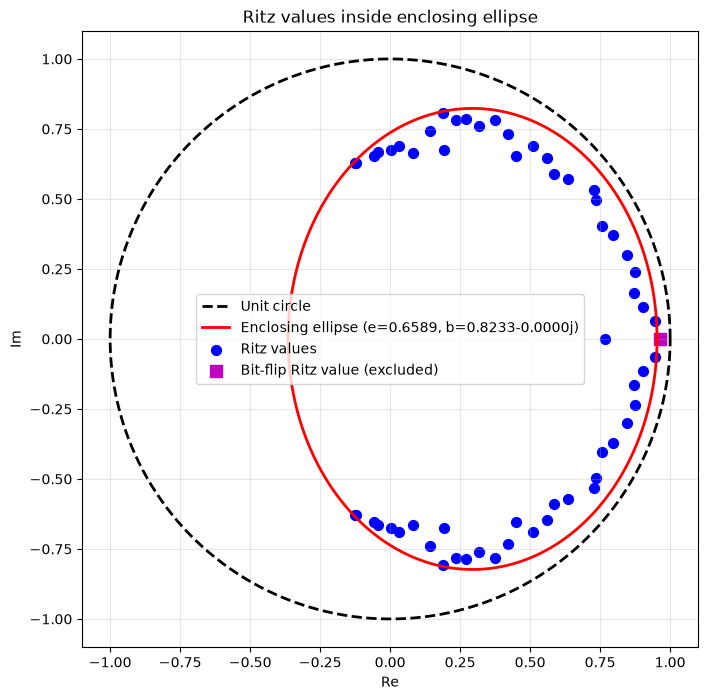

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [11]:
m_arnoldi = 120
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi)

|██████████| 100.0% ◆ elapsed 484.05ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 458.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 539.81ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 625.34ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 684.08ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 749.91ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 406.87ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 417.17ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 511.57ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 602.09ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 656.04ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 705.62ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 381.18ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 400.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 494.33ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 567.54ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 626.23ms ◆

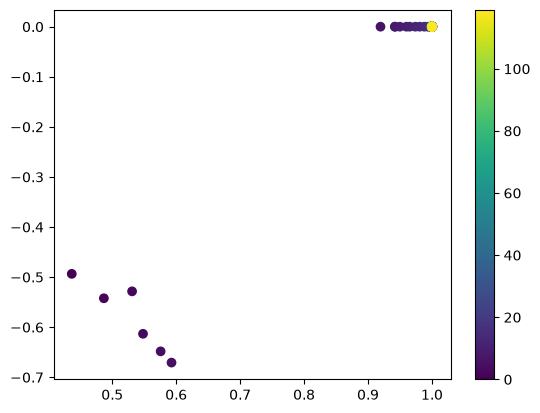

In [12]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

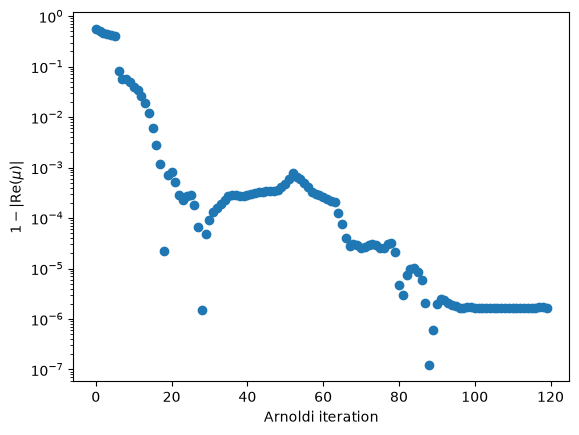

In [13]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [14]:
solver.rate_from_mu(mu_list[-1])

Array(6.80613826e-06+2.00740477e-15j, dtype=complex128)

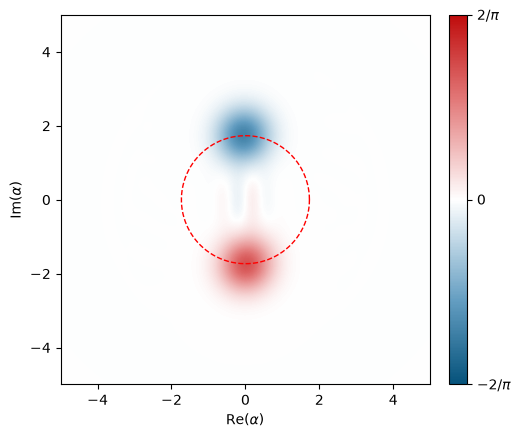

In [15]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [16]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 155.54ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.9999983+1.81679394e-16j, dtype=complex128),
 'res_rel': Array(1.44949436e-06, dtype=float64),
 'rate_RQ': Array(6.87120837e-06-7.32676368e-16j, dtype=complex128)}

In [17]:
eps_p = .1
kappa_b_init = .6/10.4
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b_init)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 153.60ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 188.40ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 211.22ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 295.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 286.41ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 286.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 376.05ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 358.25ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 352.12ms ◆ remaining 0.0

In [18]:
solver.setup_chebyshev(ritz_vals, margin=1e-5)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.24209977179895104+3.3870388660997787e-15j),
 'semi_re': np.float64(0.7578727434795658),
 'semi_im': np.complex128(1.0280883805100385+3.0527448203936107e-15j),
 'ritz_bitflip': np.complex128(0.9999825152785168+4.531921481481565e-15j),
 'vertex_x': np.complex128(0.9999725152785168+4.531921481481565e-15j),
 'margin': 1e-05,
 'max_level': 0.9999899999999999,
 'ritz_vals_enc': array([-0.1360626 +8.90950100e-01j, -0.12922992+8.91643860e-01j,
        -0.04786663+9.17053275e-01j, -0.05164829+9.05217225e-01j,
        -0.02463125+9.12078477e-01j,  0.03727974+9.32397865e-01j,
         0.03129052+9.13808408e-01j,  0.11090695+9.31817917e-01j,
         0.12056049+9.27444973e-01j,  0.18557043+9.30864342e-01j,
         0.23788567+9.13679120e-01j,  0.28402418+8.97848465e-01j,
         0.33960083+8.81997989e-01j,  0.39263213+8.53707088e-01j,
         0.44733363+8.24092360e-01j,  0.50044394+7.89669737e-01j,
         0.5598984 +7.53750105e-01j,  0.63165523+6.99874674e-01j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


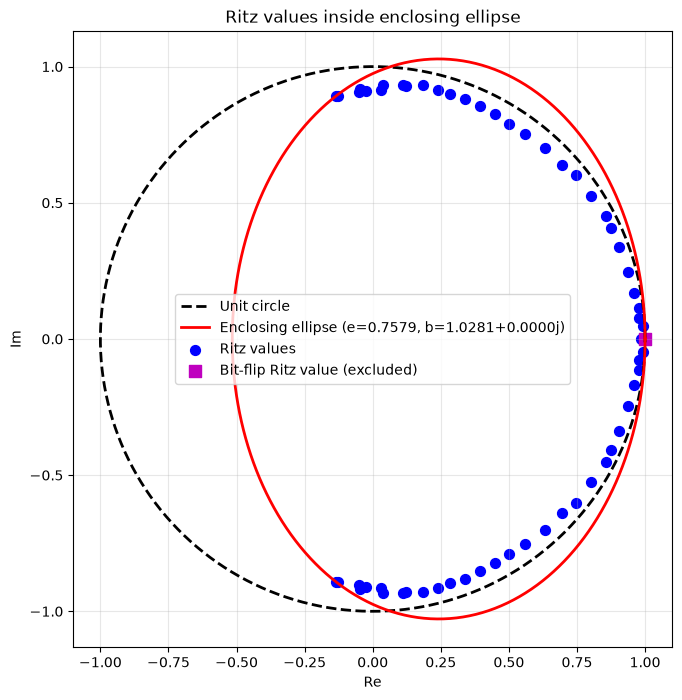

In [19]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [20]:
m_arnoldi = 180
x0 = x_ritz
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 152.84ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 151.95ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 159.57ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 182.81ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 207.08ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 233.12ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 171.04ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 174.20ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 213.15ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 251.01ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 293.83ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 340.33ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 206.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 211.08ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 255.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 295.57ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 345.92ms ◆ remai

In [21]:
m_arnoldi_new = 180
Q_new, H_new, mu_list_new = solver.arnoldi_hessenberg(
    x0, 
    solver.chebyshev_filter, 
    m_new = m_arnoldi_new,
    m_old = m_arnoldi,
    Q_old = Q,
    H_old = H,
    mu_list_old = mu_list,
    )

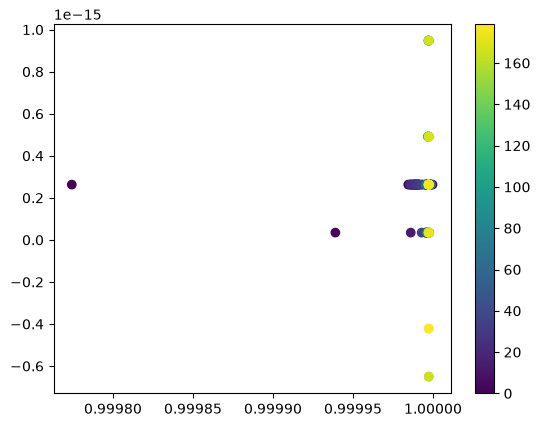

In [26]:
plt.scatter(np.real(mu_list_new), np.imag(mu_list_new), c=range(m_arnoldi_new))
plt.colorbar()
plt.show()

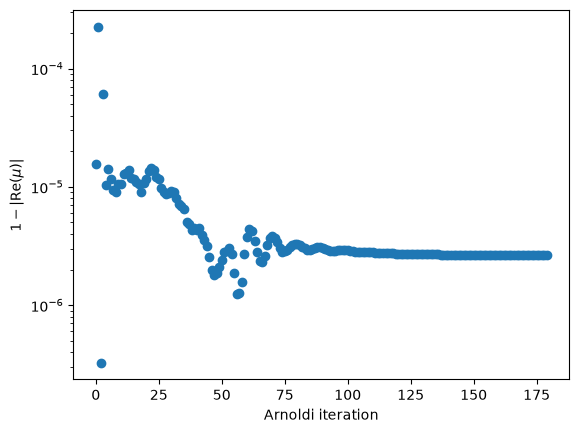

In [27]:
plt.scatter(range(m_arnoldi_new), np.abs(1-np.real(mu_list_new)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [28]:
solver.rate_from_mu(mu_list_new[-1])

Array(1.06994538e-05+1.7013451e-15j, dtype=complex128)

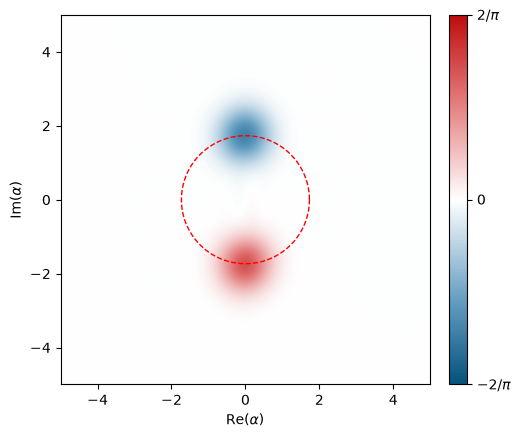

In [29]:
x_ritz, rho_ritz = solver.ritz_vector(Q_new, H_new, m_arnoldi_new, target=mu_list_new[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [30]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 166.32ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99999734+2.66650839e-16j, dtype=complex128),
 'res_rel': Array(8.49047674e-07, dtype=float64),
 'rate_RQ': Array(1.07106653e-05-1.0753501e-15j, dtype=complex128)}

In [31]:
eps_p = .2
kappa_b = kappa_b_init*jnp.sin(eps_p)/jnp.sin(eps_p_init)
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 165.54ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 213.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 293.59ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 417.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 445.54ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 454.59ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 463.59ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 479.65ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 502.54ms ◆ remaining 0.

In [32]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.03910595899253888-5.156458967932968e-16j),
 'semi_re': np.float64(0.9558787383080383),
 'semi_im': np.complex128(0.9510034150075067-5.148669446794918e-17j),
 'ritz_bitflip': np.complex128(0.9999846973005772-7.573667506905219e-16j),
 'vertex_x': np.complex128(0.9949846973005771-7.573667506905219e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000001,
 'ritz_vals_enc': array([-0.34025381+8.55596527e-01j, -0.05540923+9.43950862e-01j,
        -0.1444343 +8.95388098e-01j, -0.0591858 +9.05364674e-01j,
         0.1241109 +9.35834984e-01j,  0.14658617+8.87418386e-01j,
         0.27680314+9.00116282e-01j,  0.36030074+8.41491253e-01j,
         0.45452528+7.94258432e-01j,  0.52264192+7.58951703e-01j,
         0.61317828+6.79768908e-01j,  0.5282947 +6.82173493e-01j,
         0.71812575+5.96938917e-01j,  0.77696284+5.05054800e-01j,
         0.8189282 +4.32568348e-01j,  0.87203219+3.36199092e-01j,
         0.93212681+2.35697614e-01j,  0.91709374+1.84428558e-01j,
     

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


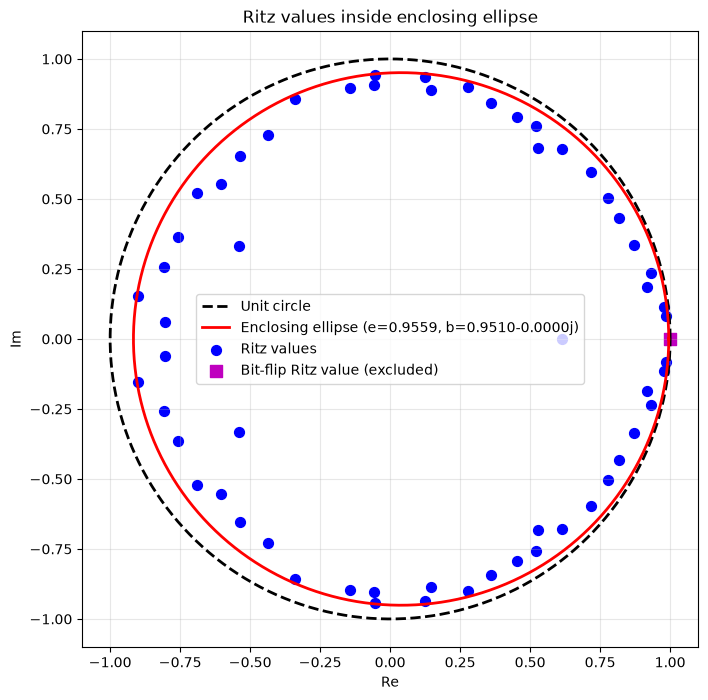

In [33]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [34]:
m_arnoldi = 100
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 164.73ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 217.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 337.21ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 482.12ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 579.33ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 669.71ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 204.34ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 303.99ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 462.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 595.27ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 670.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 731.23ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 219.51ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 339.86ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 519.53ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 632.81ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 698.46ms ◆ r

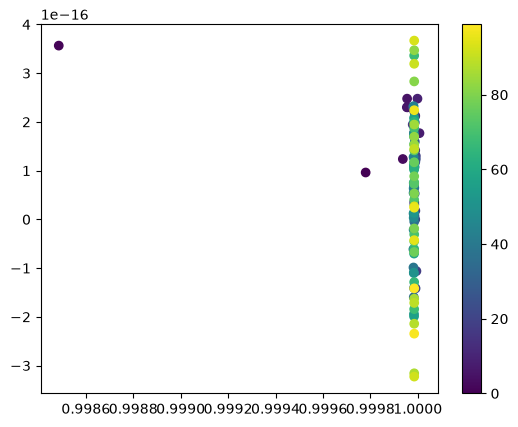

In [37]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

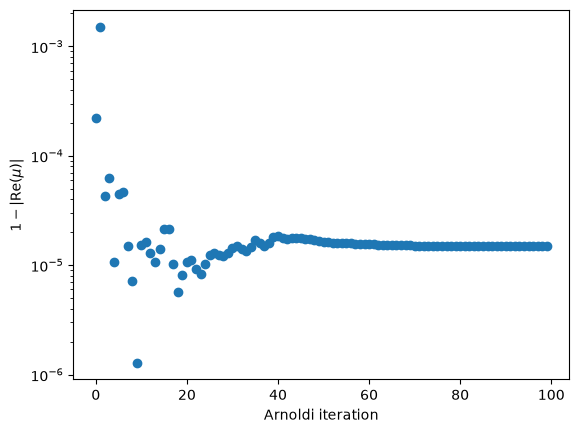

In [38]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [39]:
solver.rate_from_mu(mu_list[-1])

Array(6.0651709e-05+5.70815756e-16j, dtype=complex128)

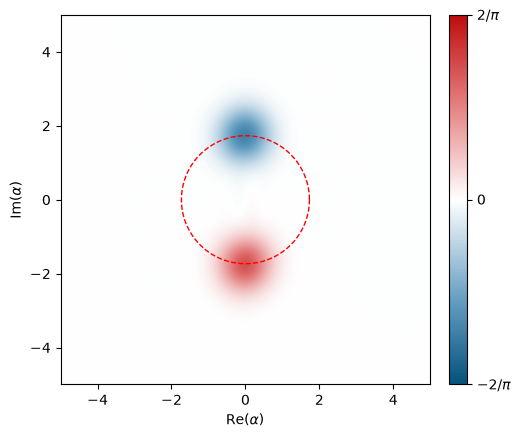

In [40]:
x_ritz, rho_ritz = solver.ritz_vector(Q_new, H_new, m_arnoldi_new, target=mu_list_new[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [41]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 167.84ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99995238-1.598114e-16j, dtype=complex128),
 'res_rel': Array(0.00839059, dtype=float64),
 'rate_RQ': Array(0.00019204+6.44516752e-16j, dtype=complex128)}

In [42]:
eps_p = .3
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 166.91ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 219.46ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 294.58ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 402.98ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 443.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 452.56ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 450.00ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 459.52ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 461.68ms ◆ remaining 0.

In [43]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.030100915501927616+2.6813203884817296e-16j),
 'semi_re': np.float64(0.9648607709101416),
 'semi_im': np.complex128(0.9360110171582328+1.2340569983588363e-16j),
 'ritz_bitflip': np.complex128(0.9999616864120692+3.955689635848692e-16j),
 'vertex_x': np.complex128(0.9949616864120692+3.955689635848692e-16j),
 'margin': 0.005,
 'max_level': 0.9949999999999997,
 'ritz_vals_enc': array([-0.88346416-1.28785871e-14j, -0.80876934-3.21198381e-01j,
        -0.80380041-1.49514206e-01j, -0.77548401-4.52382606e-01j,
        -0.73694063-5.62812728e-01j, -0.70786252-5.38190605e-01j,
        -0.60865909-6.72728399e-01j, -0.5421734 -7.49793318e-01j,
        -0.80380041+1.49514206e-01j, -0.80876934+3.21198381e-01j,
        -0.77548401+4.52382606e-01j, -0.73694063+5.62812728e-01j,
        -0.70786252+5.38190605e-01j, -0.60865909+6.72728399e-01j,
        -0.5421734 +7.49793318e-01j, -0.54498152-2.48247082e-12j,
        -0.47256367+7.25523295e-01j, -0.35314618+8.56451891e-01j,
  

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


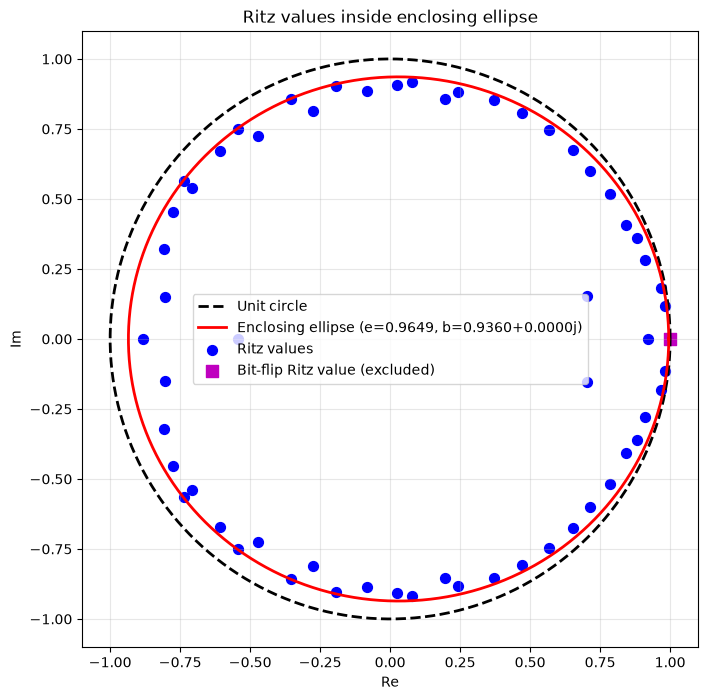

In [44]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [45]:
m_arnoldi = 80
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 165.28ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 199.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 258.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 360.29ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 469.28ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 555.77ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 195.71ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 251.74ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 354.62ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 471.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 566.77ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 634.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 197.08ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 257.45ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 370.50ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 495.57ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 596.04ms ◆ re

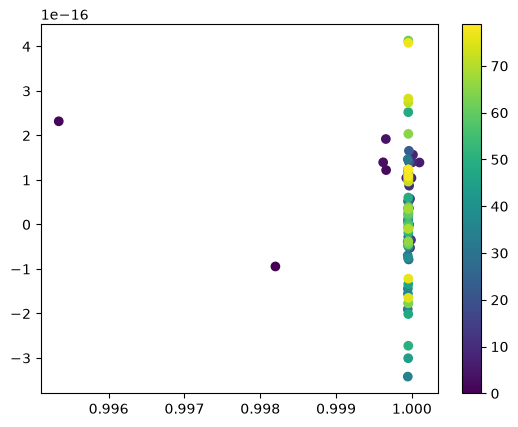

In [46]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

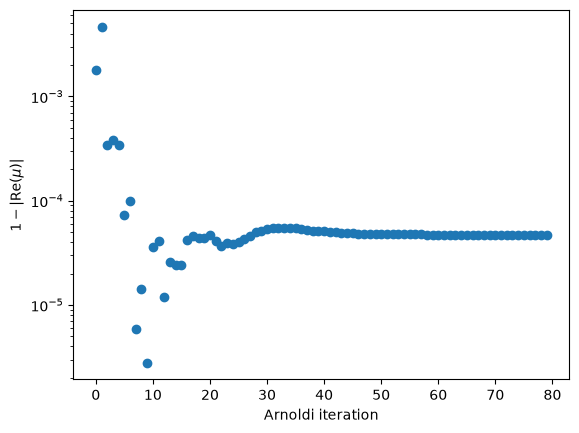

In [47]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [48]:
solver.rate_from_mu(mu_list[-1])

Array(0.00019041-4.99558409e-16j, dtype=complex128)

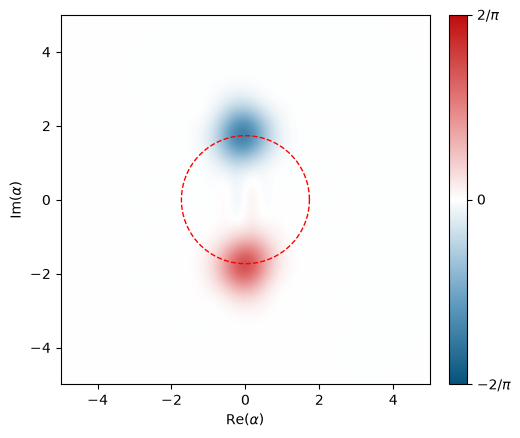

In [49]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [50]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 190.68ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99995278+7.05030855e-16j, dtype=complex128),
 'res_rel': Array(1.090863e-06, dtype=float64),
 'rate_RQ': Array(0.00019042-2.84337671e-15j, dtype=complex128)}

In [51]:
eps_p = .5
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 190.98ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 267.09ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 331.93ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 397.65ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 405.34ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 406.38ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 404.13ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 402.36ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 401.05ms ◆ remaining 0.

In [52]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.03150569391115887+6.024862116625161e-16j),
 'semi_re': np.float64(0.9633182280124453),
 'semi_im': np.complex128(0.9179731161755746+5.666487600335832e-16j),
 'ritz_bitflip': np.complex128(0.9998239219236041+8.881784197001252e-16j),
 'vertex_x': np.complex128(0.9948239219236041+8.881784197001252e-16j),
 'margin': 0.005,
 'max_level': 0.9949999999999999,
 'ritz_vals_enc': array([ 0.90629112+3.43634869e-01j,  0.96986541+1.62532680e-01j,
         0.92362984+2.17402839e-01j,  0.92678209+7.15496028e-02j,
         0.96986541-1.62532680e-01j,  0.92678209-7.15496028e-02j,
         0.92362984-2.17402839e-01j,  0.90629112-3.43634869e-01j,
         0.82781152+3.49047979e-01j,  0.80983976+4.78361873e-01j,
         0.76259838+5.21458811e-01j,  0.65047713+6.63669780e-01j,
         0.64063883+6.25378572e-01j,  0.56132455+7.26582080e-01j,
         0.82781152-3.49047979e-01j,  0.80983976-4.78361873e-01j,
         0.76259838-5.21458811e-01j,  0.65047713-6.63669780e-01j,
     

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


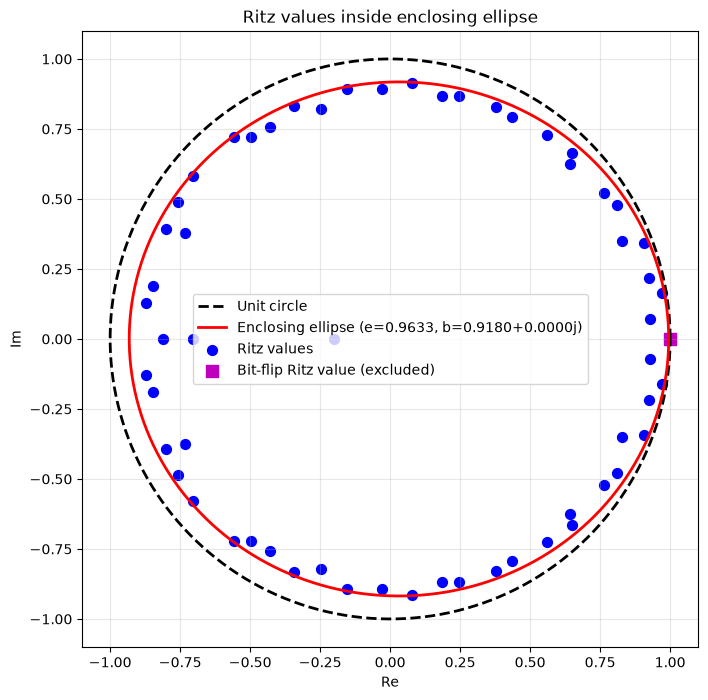

In [53]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [54]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 161.67ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 206.08ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 286.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 384.74ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 484.05ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 561.64ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 218.57ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 273.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 372.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 475.82ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 559.98ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 619.92ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 213.23ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 268.85ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 363.92ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 463.73ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 549.42ms ◆ 

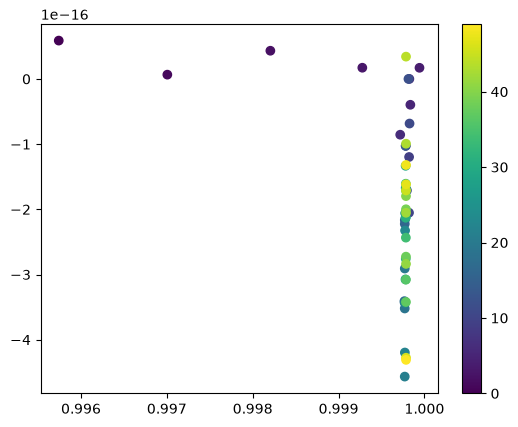

In [55]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

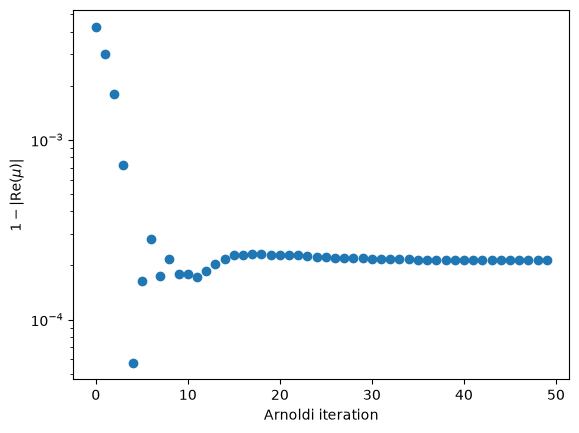

In [56]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [57]:
solver.rate_from_mu(mu_list[-1])

Array(0.00086473+1.73812269e-15j, dtype=complex128)

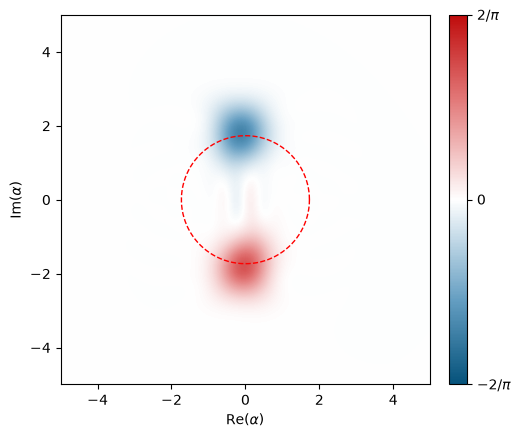

In [58]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [59]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 218.64ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.99978559+3.53028178e-17j, dtype=complex128),
 'res_rel': Array(1.88899612e-05, dtype=float64),
 'rate_RQ': Array(0.00086476-1.42399436e-16j, dtype=complex128)}

In [60]:
eps_p = .7
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b = kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 220.02ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 292.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 340.89ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 384.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 393.21ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 388.41ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 381.78ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 384.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 381.95ms ◆ remaining 0

In [61]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.04326216777163694+1.2678114712830886e-16j),
 'semi_re': np.float64(0.9512264226796114),
 'semi_im': np.complex128(0.9166125081206183+7.136009962689175e-17j),
 'ritz_bitflip': np.complex128(0.9994885904512484+1.8580316210373126e-16j),
 'vertex_x': np.complex128(0.9944885904512484+1.8580316210373126e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000001,
 'ritz_vals_enc': array([-0.78785516-4.15389613e-01j, -0.80332226-3.48351765e-01j,
        -0.72407544-4.83078884e-01j, -0.85893257-1.99226739e-01j,
        -0.87740778-1.02122915e-01j, -0.88181495-2.58186298e-14j,
        -0.87740778+1.02122915e-01j, -0.85893257+1.99226739e-01j,
        -0.74383632+1.78407130e-14j, -0.80332226+3.48351765e-01j,
        -0.78785516+4.15389613e-01j, -0.72407544+4.83078884e-01j,
        -0.61800955-6.54881298e-01j, -0.52289492-6.61969394e-01j,
        -0.52145287-6.34919698e-01j, -0.39281384-8.12036354e-01j,
        -0.29592564-7.94019794e-01j, -0.16186064-8.84865526e-01j,
  

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


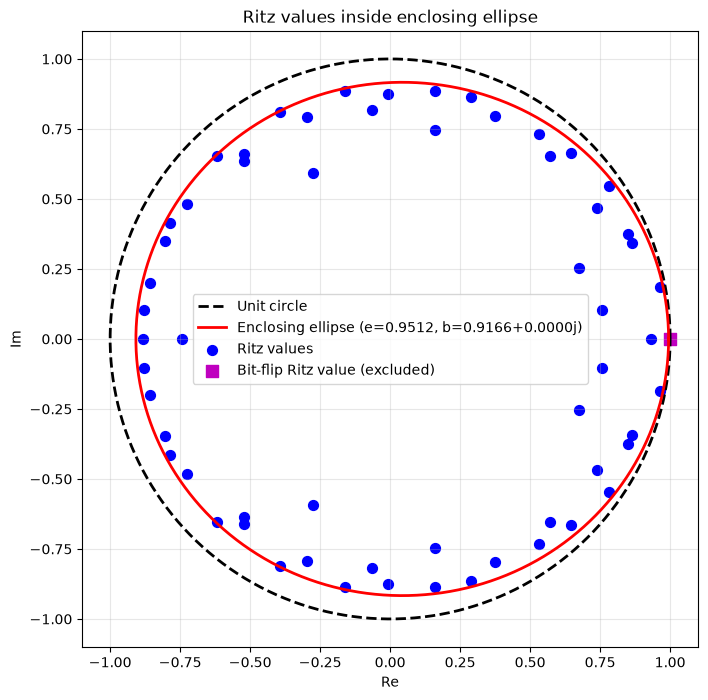

In [62]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [63]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 188.26ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 248.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 358.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 484.48ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 590.41ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 660.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 252.60ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 331.81ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 451.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 556.78ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 629.74ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 691.40ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 259.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 329.09ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 450.09ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 561.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 630.07ms ◆ 

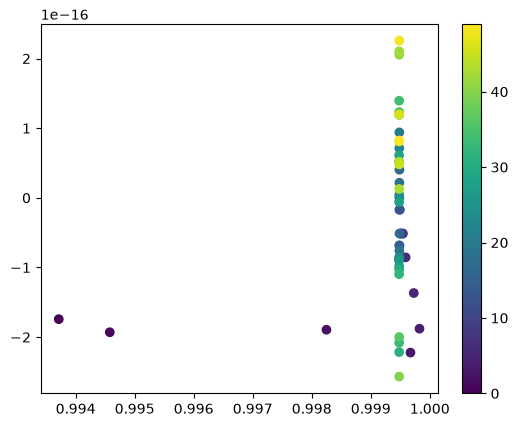

In [68]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

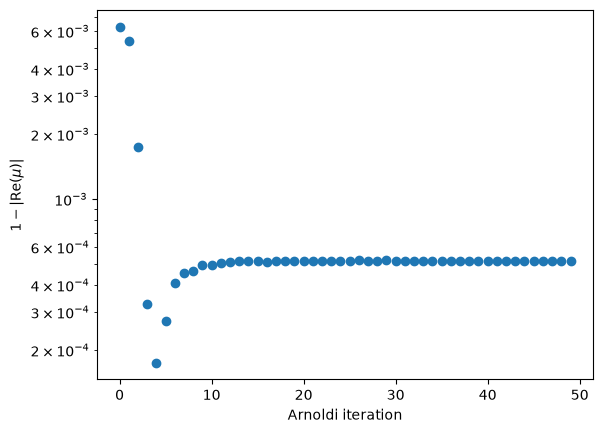

In [69]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [70]:
solver.rate_from_mu(mu_list[-1])

Array(0.00209033-3.31767949e-16j, dtype=complex128)

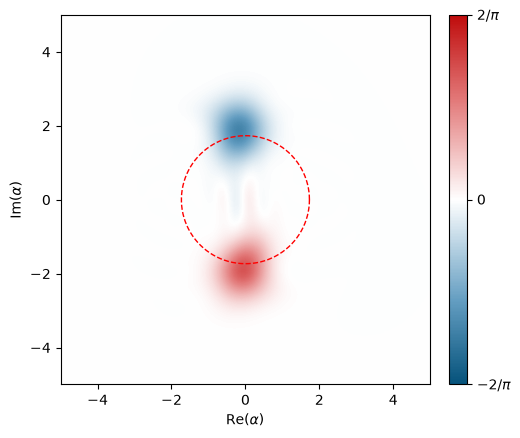

In [71]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [72]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 235.10ms ◆ remaining 0.00ms  


{'mu_RQ': Array(0.99948182-1.58333308e-16j, dtype=complex128),
 'res_rel': Array(2.06397678e-05, dtype=float64),
 'rate_RQ': Array(0.00209025+6.38856264e-16j, dtype=complex128)}

In [74]:
eps_p = .9
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b=kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 246.01ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 311.46ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 351.14ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 359.94ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 360.98ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 340.71ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 344.12ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 314.27ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 347.01ms ◆ remaining 0.00ms
|█████████

In [75]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.03991143928093832-2.316597805697652e-16j),
 'semi_re': np.float64(0.9540564969324216),
 'semi_im': np.complex128(0.8974407684661426-3.838858302944267e-17j),
 'ritz_bitflip': np.complex128(0.9989679362133599-3.400058012914542e-16j),
 'vertex_x': np.complex128(0.9939679362133599-3.400058012914542e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000002,
 'ritz_vals_enc': array([ 0.95838131-1.85695505e-01j,  0.95838131+1.85695505e-01j,
         0.9580676 +3.76278592e-15j,  0.88154108-3.53501774e-01j,
         0.85430643-1.50186611e-01j,  0.56172511-7.46959111e-01j,
         0.78345874-3.25133523e-01j,  0.71749469-5.60497327e-01j,
         0.73342497-4.82905199e-01j,  0.57128421-6.66969642e-01j,
         0.63460126-5.38031698e-01j,  0.39623286-8.15243890e-01j,
         0.36830309-7.66944491e-01j,  0.26675507-8.46667617e-01j,
         0.13310204-8.23966080e-01j,  0.03343629-8.80145136e-01j,
        -0.12245193-8.82069710e-01j, -0.10551486-8.49461161e-01j,
     

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


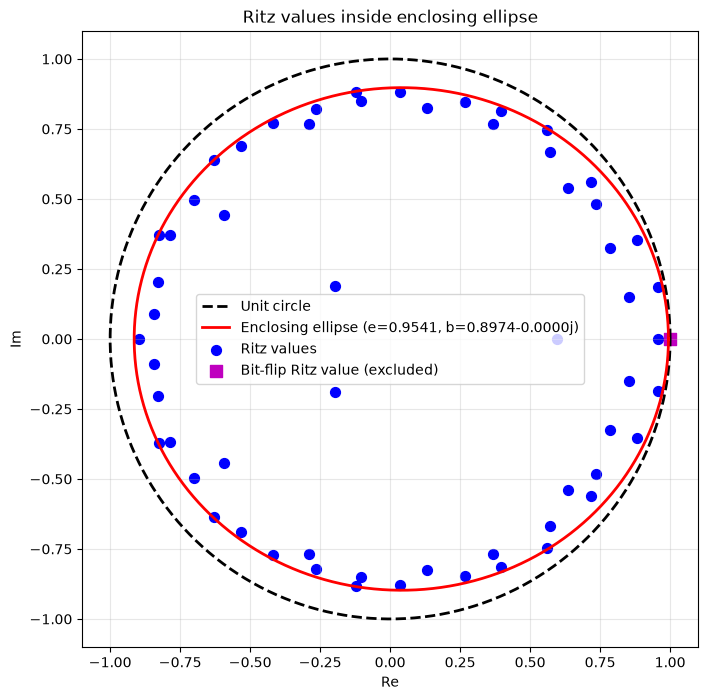

In [76]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [77]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 247.65ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 272.60ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 369.12ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 486.59ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 575.81ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 621.44ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 273.55ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 316.77ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 449.23ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 558.64ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 628.20ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 680.76ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 266.34ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 314.05ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 445.76ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 543.70ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 610.48ms ◆ remaining 0.00ms
|██████████| 1

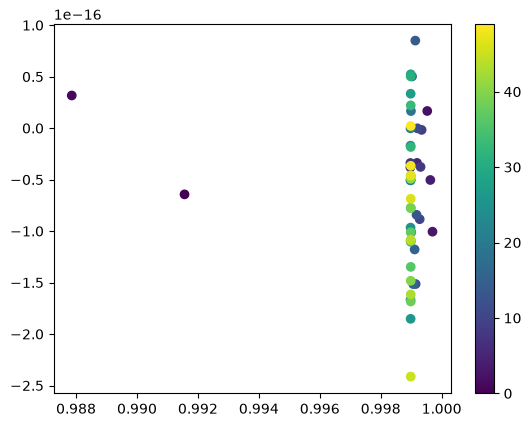

In [78]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

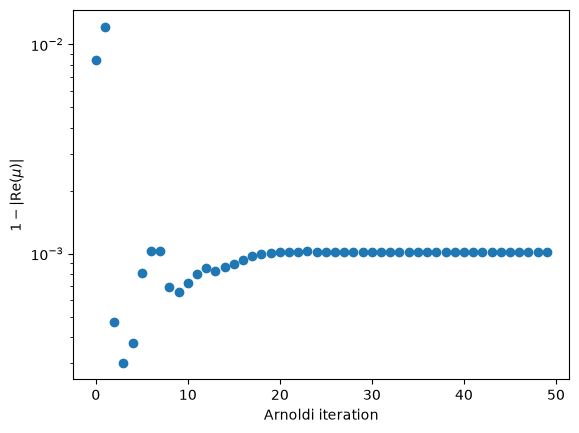

In [82]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [83]:
solver.rate_from_mu(mu_list[-1])

Array(0.0040952-8.40433739e-18j, dtype=complex128)

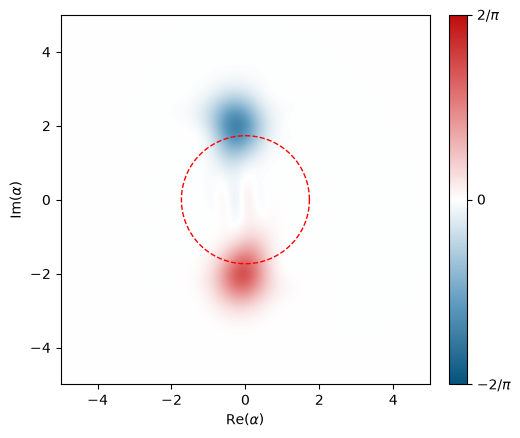

In [84]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [85]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 254.45ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99898507+2.42959271e-16j, dtype=complex128),
 'res_rel': Array(3.7583662e-05, dtype=float64),
 'rate_RQ': Array(0.00409507-9.8079953e-16j, dtype=complex128)}

In [86]:
eps_p = 1.1
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b=kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 251.64ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 307.00ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 304.97ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 300.82ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 300.32ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 296.95ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 310.79ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 308.87ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 313.97ms ◆ remaining 0.00ms
|█████████

In [87]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.047389563415463076+1.3342100145219927e-16j),
 'semi_re': np.float64(0.9443744024233606),
 'semi_im': np.complex128(0.9114367289356257-3.987872103122592e-17j),
 'ritz_bitflip': np.complex128(0.9967639658388237+1.9496241367174443e-16j),
 'vertex_x': np.complex128(0.9917639658388236+1.9496241367174443e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000001,
 'ritz_vals_enc': array([-0.85493596-2.54632056e-01j, -0.87315335-1.55838969e-01j,
        -0.85493596+2.54632056e-01j, -0.87315335+1.55838969e-01j,
        -0.83656259-9.67099965e-02j, -0.83656259+9.67099965e-02j,
        -0.74408157+2.95095039e-01j, -0.73439973+3.83995394e-01j,
        -0.69157397+5.41686552e-01j, -0.66868099+5.67503747e-01j,
        -0.74408157-2.95095039e-01j, -0.73439973-3.83995394e-01j,
        -0.69157397-5.41686552e-01j, -0.66868099-5.67503747e-01j,
        -0.53950321+6.52785027e-01j, -0.44576015+7.57530546e-01j,
        -0.3910077 +7.77961121e-01j, -0.27980403+8.29430062e-01j,
 

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


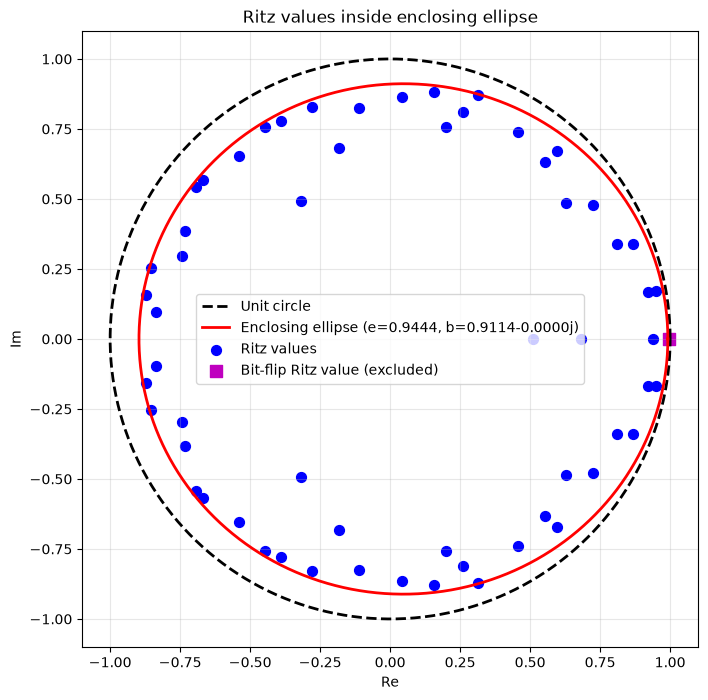

In [88]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [89]:
m_arnoldi = 30
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 258.02ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 293.71ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 408.86ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 525.48ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 587.68ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 631.03ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 273.80ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 355.86ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 478.32ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 572.61ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 609.12ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 651.17ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 269.44ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 351.52ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 473.27ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 557.73ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 613.20ms ◆ remaining 0.00ms
|██████████| 1

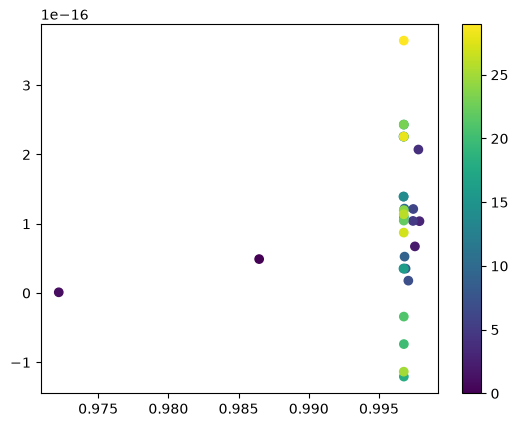

In [90]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

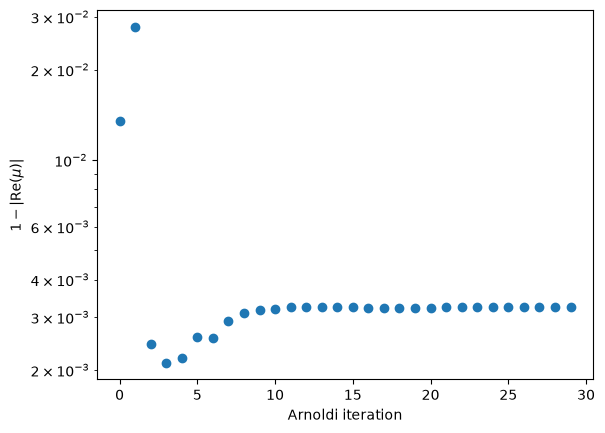

In [91]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [92]:
solver.rate_from_mu(mu_list[-1])

Array(0.01305848-1.47434175e-15j, dtype=complex128)

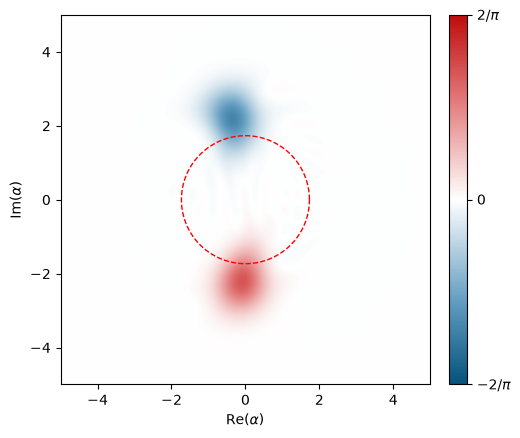

In [93]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [94]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 259.64ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99676744+1.90759231e-17j, dtype=complex128),
 'res_rel': Array(9.11848582e-05, dtype=float64),
 'rate_RQ': Array(0.01305737-7.71787062e-17j, dtype=complex128)}

In [97]:
eps_p = 1.3
kappa_b = jnp.sin(eps_p)/jnp.sin(eps_p_init)*kappa_b_init
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p, kappa_b=kappa_b)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 263.83ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 279.80ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 280.92ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 284.97ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 290.83ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 297.47ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 297.60ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 305.05ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 313.70ms ◆ remaining 0.00ms
|█████████

In [98]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.04522602475683568+2.2880040346502697e-16j),
 'semi_re': np.float64(0.9346633305557847),
 'semi_im': np.complex128(0.9148598616062762-2.18232825425286e-17j),
 'ritz_bitflip': np.complex128(0.9848893553126203+3.3336152079197447e-16j),
 'vertex_x': np.complex128(0.9798893553126203+3.3336152079197447e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000002,
 'ritz_vals_enc': array([ 0.13500938-9.08328490e-01j,  0.13063893-8.71676376e-01j,
        -0.0241928 -8.78632144e-01j, -0.34068776-8.05127360e-01j,
        -0.18351865-8.00144054e-01j, -0.09762316-7.98749721e-01j,
        -0.40123391-7.25936597e-01j, -0.53720084-6.78280006e-01j,
        -0.61602133-6.29516483e-01j, -0.73183955-4.87366521e-01j,
        -0.81326267-3.35080536e-01j, -0.65179189-4.64777905e-01j,
        -0.5239906 -5.09507858e-01j, -0.81782045-1.84524015e-01j,
        -0.70011648-2.26499275e-01j, -0.88330786-4.62044955e-02j,
        -0.88330786+4.62044955e-02j, -0.71636951+1.05363051e-15j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


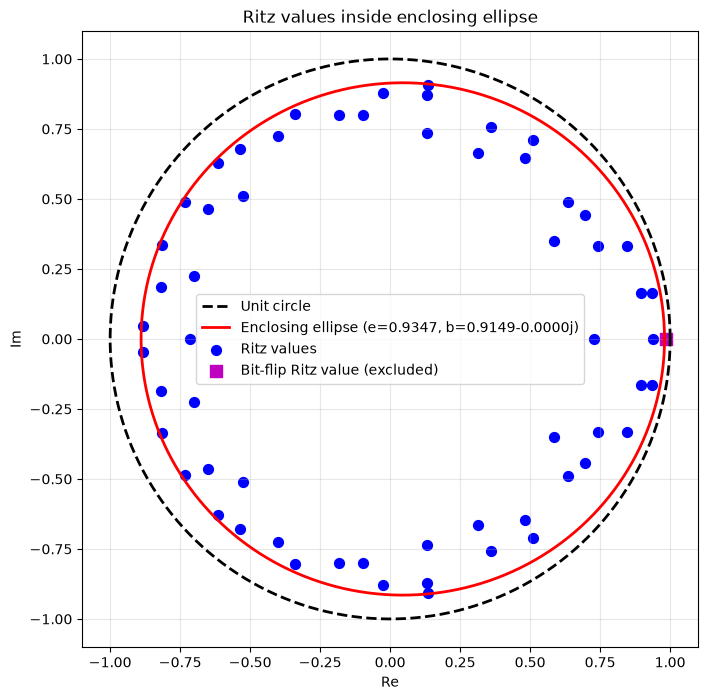

In [99]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [100]:
m_arnoldi = 30
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 267.58ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 323.61ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 443.31ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 540.24ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 605.11ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 640.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 292.74ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 384.47ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 504.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 583.75ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 630.15ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 673.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 278.38ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 366.85ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 494.10ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 568.18ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 621.36ms ◆ remaining 0.00ms
|██████████| 1

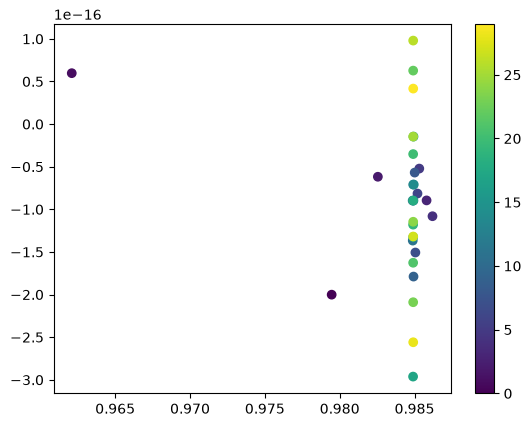

In [101]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

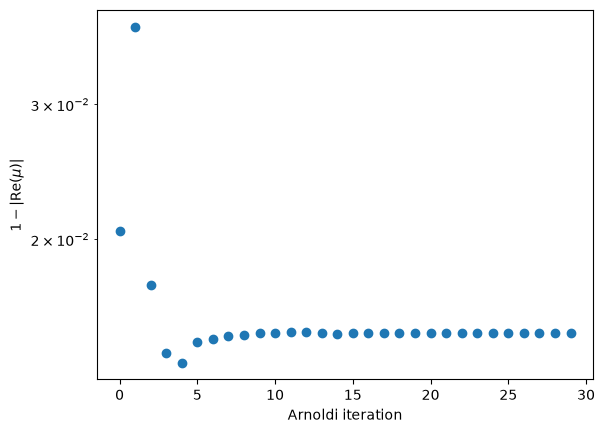

In [102]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [103]:
solver.rate_from_mu(mu_list[-1])

Array(0.06131385-1.70548496e-16j, dtype=complex128)

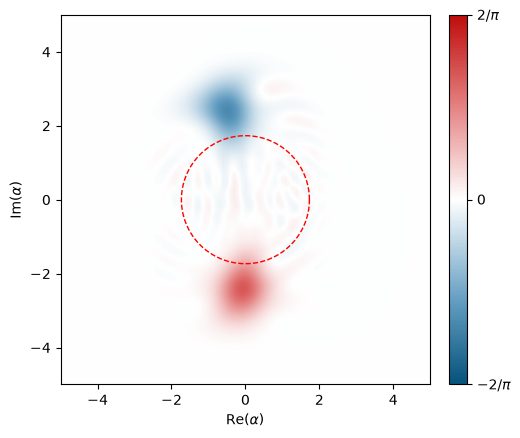

In [104]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [105]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 278.33ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.9849118-4.94853588e-17j, dtype=complex128),
 'res_rel': Array(0.00029123, dtype=float64),
 'rate_RQ': Array(0.06131128+2.02621327e-16j, dtype=complex128)}